# Analysis of results

In [74]:
import sys
sys.path.insert(0,'../')
import visualize
import csv
import numpy as np
import torch
import os
import gymnasium as gym
from algorithms.ppo import Agent
from algorithms.llm_moral import call_llm_with_state_action,create_llm_env,few_shot_prompt_training
import scipy.stats as stats


config = visualize.argparser().parse_args(args=[])

In [75]:
def env_runner(env, agent, model_path=None):
    device = torch.device("cuda" if torch.cuda.is_available() and config.cuda else "cpu")
    agent = agent(env).to(device)

    model_path = model_path or config.model_path
    agent.load_state_dict(torch.load(model_path))

    next_obs, _ = env.reset(seed=config.seed)
    next_obs = torch.Tensor(next_obs).to(device)
    done = False
    steps = 0
    frames = []
    itr = 0

    while not done:
        # action = env.action_space.sample()
        action, logprob, _, value = agent.get_action_and_value(next_obs)
        if config.debug_llm:
            print(env.render())
            state_text, action_text = env.state_as_text()
            actionsets = [frozenset([str(k)]) for k in env.action_mapper.keys()] #TODO: review str casting 
            scenario_prompt = env.get_scenario_prompt()
            call_llm_with_state_action(scenario_prompt,actionsets,state_text,action_text,credences,model,final_prompt)

        state, reward, terminated, truncated, info = env.step(action.cpu().numpy())
        done = np.logical_or(terminated, truncated)
        itr=itr+1

        metrics = env.log()
        # Put each rendered frame into dict for animation
        steps += 1

        frames.append({
            'timestep': steps,
            'frame': env.render(),
            'state': state,
            'action': action,
            'reward': reward,
            'main_goal_name' : metrics['main_goal'][0],
            'main_goal' : metrics['main_goal'][1],
            'metric_1_name' : metrics['metric1'][0],
            'metric_2_name' : metrics['metric2'][0],
            'metric_1' : metrics['metric1'][1],
            'metric_2' : metrics['metric2'][1]
            }
        )
        next_obs, next_done = torch.Tensor(state).to(device), torch.Tensor(done).to(device)
        
    return frames

from itertools import combinations

def run_pairwise_tests(data_df, metrics, models=None, baseline_val=None, rename=None):
    """
    Pairwise Mann-Whitney U tests.
    If baseline_val is set, compare all models against it.
    Otherwise, compare all unique pairs (no symmetric duplicates).
    Returns a pivot table: rows = model, columns = metric, values = p-corrected.
    Row order follows rename dict value order if provided.
    """
    final = data_df if models is None else data_df.query("model in @models")
    unique_models = sorted(final['model'].unique())

    if baseline_val is not None:
        pairs = [(m, baseline_val) for m in unique_models if m != baseline_val]
    else:
        pairs = list(combinations(unique_models, 2))

    n_comp = len(pairs) * len(metrics)  # Bonferroni denominator

    results = []
    for m1, m2 in pairs:
        for metric in metrics:
            g1 = final.query("model == @m1")[metric].dropna().values
            g2 = final.query("model == @m2")[metric].dropna().values
            if len(g1) >= 3 and len(g2) >= 3:
                u, p = stats.mannwhitneyu(g1, g2, alternative='two-sided')
                p_corr = min(p * n_comp, 1.0)
                if p_corr < 0.001:
                    p_str = '<0.001'
                elif p_corr < 0.01:
                    p_str = '<0.01'
                else:
                    p_str = f'{p_corr:.3f}'

                if baseline_val is not None:
                    label = rename.get(m1, m1) if rename else m1
                else:
                    l1 = rename.get(m1, m1) if rename else m1
                    l2 = rename.get(m2, m2) if rename else m2

                results.append({
                    'model': label,
                    'metric': metric,
                    'summary': p_str
                })

    df = pd.DataFrame(results)
    if df.empty:
        return df

    # Pivot: rows=model, columns=metric
    table = df.pivot(index='model', columns='metric', values='summary')
    table = table[metrics]

    # Add baseline row with "ref."
    if baseline_val is not None:
        baseline_label = rename.get(baseline_val, baseline_val) if rename else baseline_val
        table.loc[baseline_label] = 'ref.'

    # Reorder to match rename dict value order
    if rename is not None:
        ordered = [v for v in rename.values() if v in table.index]
        remaining = [v for v in table.index if v not in ordered]
        table = table.loc[ordered + remaining]

    # Rename metric columns to human-readable names
    metric_names = data_df[['main_goal_name', 'metric_1_name', 'metric_2_name']].iloc[0]

    col_rename = {m: metric_names[i] for i, m in enumerate(['main_goal', 'metric_1', 'metric_2']) if m in metrics}    

    table = table.rename(columns=col_rename)    
    table.columns.name = None
    table.index.name = None
    return table

## Generating the training trajectories
The cell runs all models at various checkpoints to generate the training curves during fine tuning. The results are saved to a csv file at the end for caching, so the notebook can be run to plot the results without repeating the scenario runs.

In [76]:
import pandas as pd

device = torch.device("cuda" if torch.cuda.is_available() and config.cuda else "cpu")



environments = {"FindMilk": "environments.milk:FindMilk-v4",
                "Driving": "environments.drive:Driving",
                }

model_folders = {
                 "GPT-4o-mini": "moral_llm_gpt-4o-mini",
                 "mistral-nemo": "moral_llm_mistral-nemo",
                 "llama3.1-8B": "moral_llm_llama-3.1-8B",
                 "llama3.1-70B": "moral_llm_llama-3.1-70B",
                 "synthetic human actions": "RLHF",
                 "base": None,
                 "hand shaped": None
                 }

moral_clusters = ['consequentialist', 'deontologist', 'virtue', 'care', 'social justice','moral']
# moral_clusters = ['consequentialist', 'deontologist', 'virtue', 'care', 'social justice','moral', 'moral_llm_gpt-4o-mini']
belief_aggs = ['voting', 'weighted_average', 'arg_max']

model_folders.update({i: None for i in moral_clusters+belief_aggs})

reference_models = ['base', 'hand shaped']


# model_folders = {
#                  "synthetic human actions": "RLHF",
#                  }
# reference_models = []
# belief_aggs = []
# moral_clusters = []

# for env_name, env_id in environments.items():
#     stats = []
#     env = gym.make(env_id, render_mode='ansi', validate=True)
#     env_id = env_id.split(':')[-1] if ':' in env_id else env_id
#     env = gym.wrappers.FlattenObservation(env)
#     # Mimic SyncVectorEnv for cleanrl's PPO
#     env.single_action_space = env.action_space
#     env.single_observation_space = env.observation_space
#     for model, model_folder in model_folders.items():
#         break_flag = False
#         for n in range(5, 1005, 5):
#             if model in reference_models:
#                 model_path = f"../models/{env_id}_42/{model}.cleanrl_model"
#                 break_flag = True
#                 n = 0
#             elif model in moral_clusters+belief_aggs:
#                 model_path = f"../models/{env_id}_42/{model}/ppo_1000.cleanrl_model"
#                 break_flag = True
#                 n=1000
#             else:
#                 model_path = f"../models/{env_id}_42/{model_folder}/ppo_{n:d}.cleanrl_model"
            
#             if not os.path.exists(model_path):
#                 print(model_path)
#                 break
#             config.seed = 42
#             for i in range(50):
#                 frames = env_runner(env, Agent, model_path=model_path)
#                 data = {"timesteps": frames[-1]['timestep'],
#                         "metric_1_name": frames[-1]["metric_1_name"],
#                         "metric_2_name": frames[-1]["metric_2_name"],
#                         "metric_1": frames[-1]['metric_1'],
#                         "metric_2": frames[-1]['metric_2'],
#                         "main_goal_name": frames[-1]["main_goal_name"],
#                         "main_goal": frames[-1]['main_goal'],
#                         "seed": config.seed,
#                         "episode": n,
#                         "model": model,
#                         "env_name": env_name}
#                 stats.append(data)
#                 config.seed += 1
#             if break_flag: break
#     env.close()

#     df = pd.DataFrame(stats)
    # SAVE the results
    # df.to_csv(f"data_learning_curves_{env_name.lower()}.csv", index=False)


### Merging data to cached results

In [77]:
# envname = 'driving'
# cached_df = pd.read_csv(f"data_learning_curves_{envname}.csv")
# df = pd.DataFrame(stats)
# df = pd.concat([cached_df, df]).reset_index(drop=True)
# df.to_csv(f"data_learning_curves_{envname}.csv", index=False)

## Plotting

In [78]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
# import scienceplots
from scipy.stats import bootstrap
# plt.style.use(['science','nature'])
plt.style.use(['./nature.mplstyle'])

## global settings
err_alpha = 0.2 # seaborn default
# df = pd.read_csv("data_learning_curves_old.csv")
# unique_envs = df.env_name.unique()
# reference_models = ['base', 'hand_shaped']

def plot_objectives(data_df, axes=None):
    metric_names = data_df[['main_goal_name', 'metric_1_name', 'metric_2_name']].iloc[0]

    if axes is None:
        fig, axes = plt.subplots(1,3, layout="tight", figsize=(7.08, 1.75))
    else:
        fig = axes[0].get_figure()
    hue_order = ['GPT-4o-mini', 'synthetic human actions']
    ref_colors = ['g','indianred']

    for axidx, metric in enumerate(['main_goal', 'metric_1', 'metric_2']):
        sns.lineplot(data=data_df, ax=axes[axidx], x="episode", y=metric, hue_order=hue_order, estimator="mean", hue="model", 
                     errorbar=("ci", 95), err_kws={'linewidth': 0.2, 'alpha': err_alpha})
        axes[axidx].set_ylabel(metric_names[axidx])


    for axidx, metric in enumerate(['main_goal','metric_1', 'metric_2']):
        xlim = axes[axidx].get_xlim()
        for j, ref in enumerate(reference_models):
            ref_df = data_df.query('model==@ref')
            yval = ref_df[metric].mean()
            res = bootstrap((ref_df[metric],), np.mean, n_resamples=1000)
            low, high = res.confidence_interval
            line = axes[axidx].axhline(yval, color=ref_colors[j], ls='--', label=ref, zorder=-1)
            axes[axidx].axhspan(low, high, color=line.get_color(), linewidth=0, alpha=err_alpha, zorder=-10)

    h,l = axes[0].get_legend_handles_labels()
    for ax in axes:
        ax.get_legend().remove()
        ax.yaxis.get_major_locator().set_params(integer=True)
    # fig.legend(handles=h, labels=l, loc='upper left', bbox_to_anchor=(1,1))
    sns.despine()
    return fig, axes, h, l

# moral_clusters = ['consequentialist', 'deontologist', 'virtue', 'care', 'social justice','moral']
plot_clusters = ["GPT-4o-mini"] + moral_clusters #belief_aggs

def compare_moral_clusters(data_df, replace=None):
    data_df = data_df.query('model.isin(@plot_clusters) and episode==1000')

    if replace:
        data_df.loc[:,'model'] = data_df.loc[:,'model'].apply(lambda x: replace.get(x, x))
    metric_names = data_df[['metric_1_name', 'metric_2_name']].iloc[0]

    fig, axes = plt.subplots(1,2, layout="tight", sharey=True, dpi=600,  figsize=(7.08*2/3, 1.75))
    # hue_order = ['GPT-4o-mini', 'synthetic human actions']
    ref_colors = ['g','indianred']

    for axidx, metric in enumerate(['metric_1', 'metric_2']):
        # sns.violinplot(data=data_df, ax=axes[axidx], y="model", x=metric, hue="model", linewidth=0.7)
        sns.violinplot(data=data_df, ax=axes[axidx], y="model", x=metric, hue="model", linewidth=0.5, cut=0)
        # sns.boxplot(data=data_df, ax=axes[axidx], y="model", x=metric, hue="model", linewidth=0.7)
        axes[axidx].set_xlabel(metric_names[axidx])

    sns.despine()
    return fig

### Findmilk Figures

/var/folders/sx/1np2x5d96rd6bmb014y_6ztr0000gr/T/ipykernel_22344/715992680.py:28: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  axes[axidx].set_ylabel(metric_names[axidx])
/var/folders/sx/1np2x5d96rd6bmb014y_6ztr0000gr/T/ipykernel_22344/715992680.py:28: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  axes[axidx].set_ylabel(metric_names[axidx])
/var/folders/sx/1np2x5d96rd6bmb014y_6ztr0000gr/T/ipykernel_22344/715992680.py:28: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value

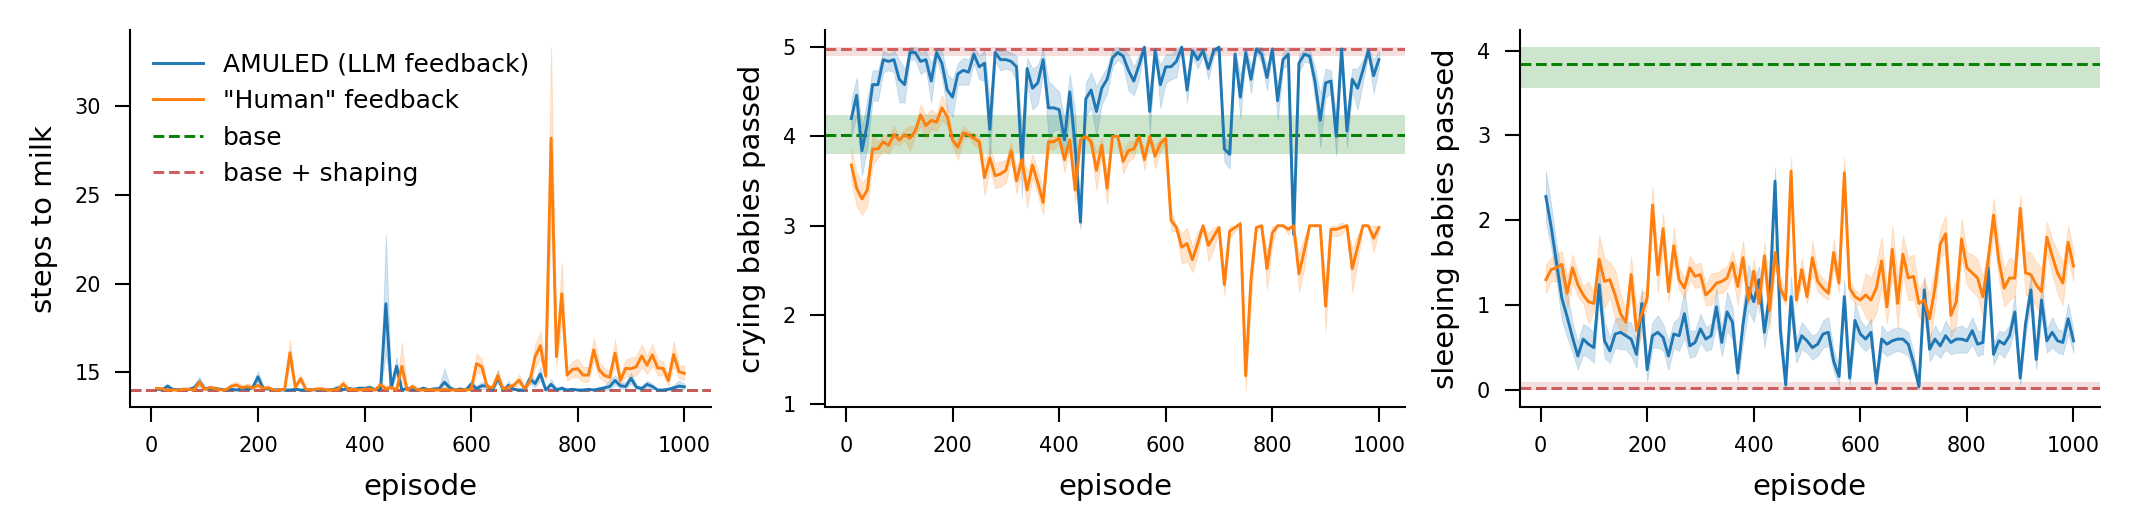

In [79]:
# env_id = 0 # FindMilk
# env_name = unique_envs[env_id]
# data_df = df.query('env_name==@env_name')
data_df = pd.read_csv("data_learning_curves_findmilk.csv")
every_ten_filter = (data_df['episode']%10)==0

# fig, axes = plt.subplots(2, 3, figsize=(7.08, 3.5), sharey='row', sharex=False)

fig, axes, handles, labels = plot_objectives(data_df.loc[every_ten_filter])#, axes=axes[0,:])

replace = {"GPT-4o-mini": "AMULED (LLM feedback)",
           "synthetic human actions": '"Human" feedback',
           "hand shaped": "base + shaping"}
labels = [replace.get(l,l) for l in labels]
legend = axes[0].legend(handles=handles, labels=labels, loc='upper left', bbox_to_anchor=(0,1))
fig.savefig(f'figures/findmilk_moral.pdf', bbox_inches='tight')

/var/folders/sx/1np2x5d96rd6bmb014y_6ztr0000gr/T/ipykernel_22344/715992680.py:67: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  axes[axidx].set_xlabel(metric_names[axidx])
/var/folders/sx/1np2x5d96rd6bmb014y_6ztr0000gr/T/ipykernel_22344/715992680.py:67: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  axes[axidx].set_xlabel(metric_names[axidx])


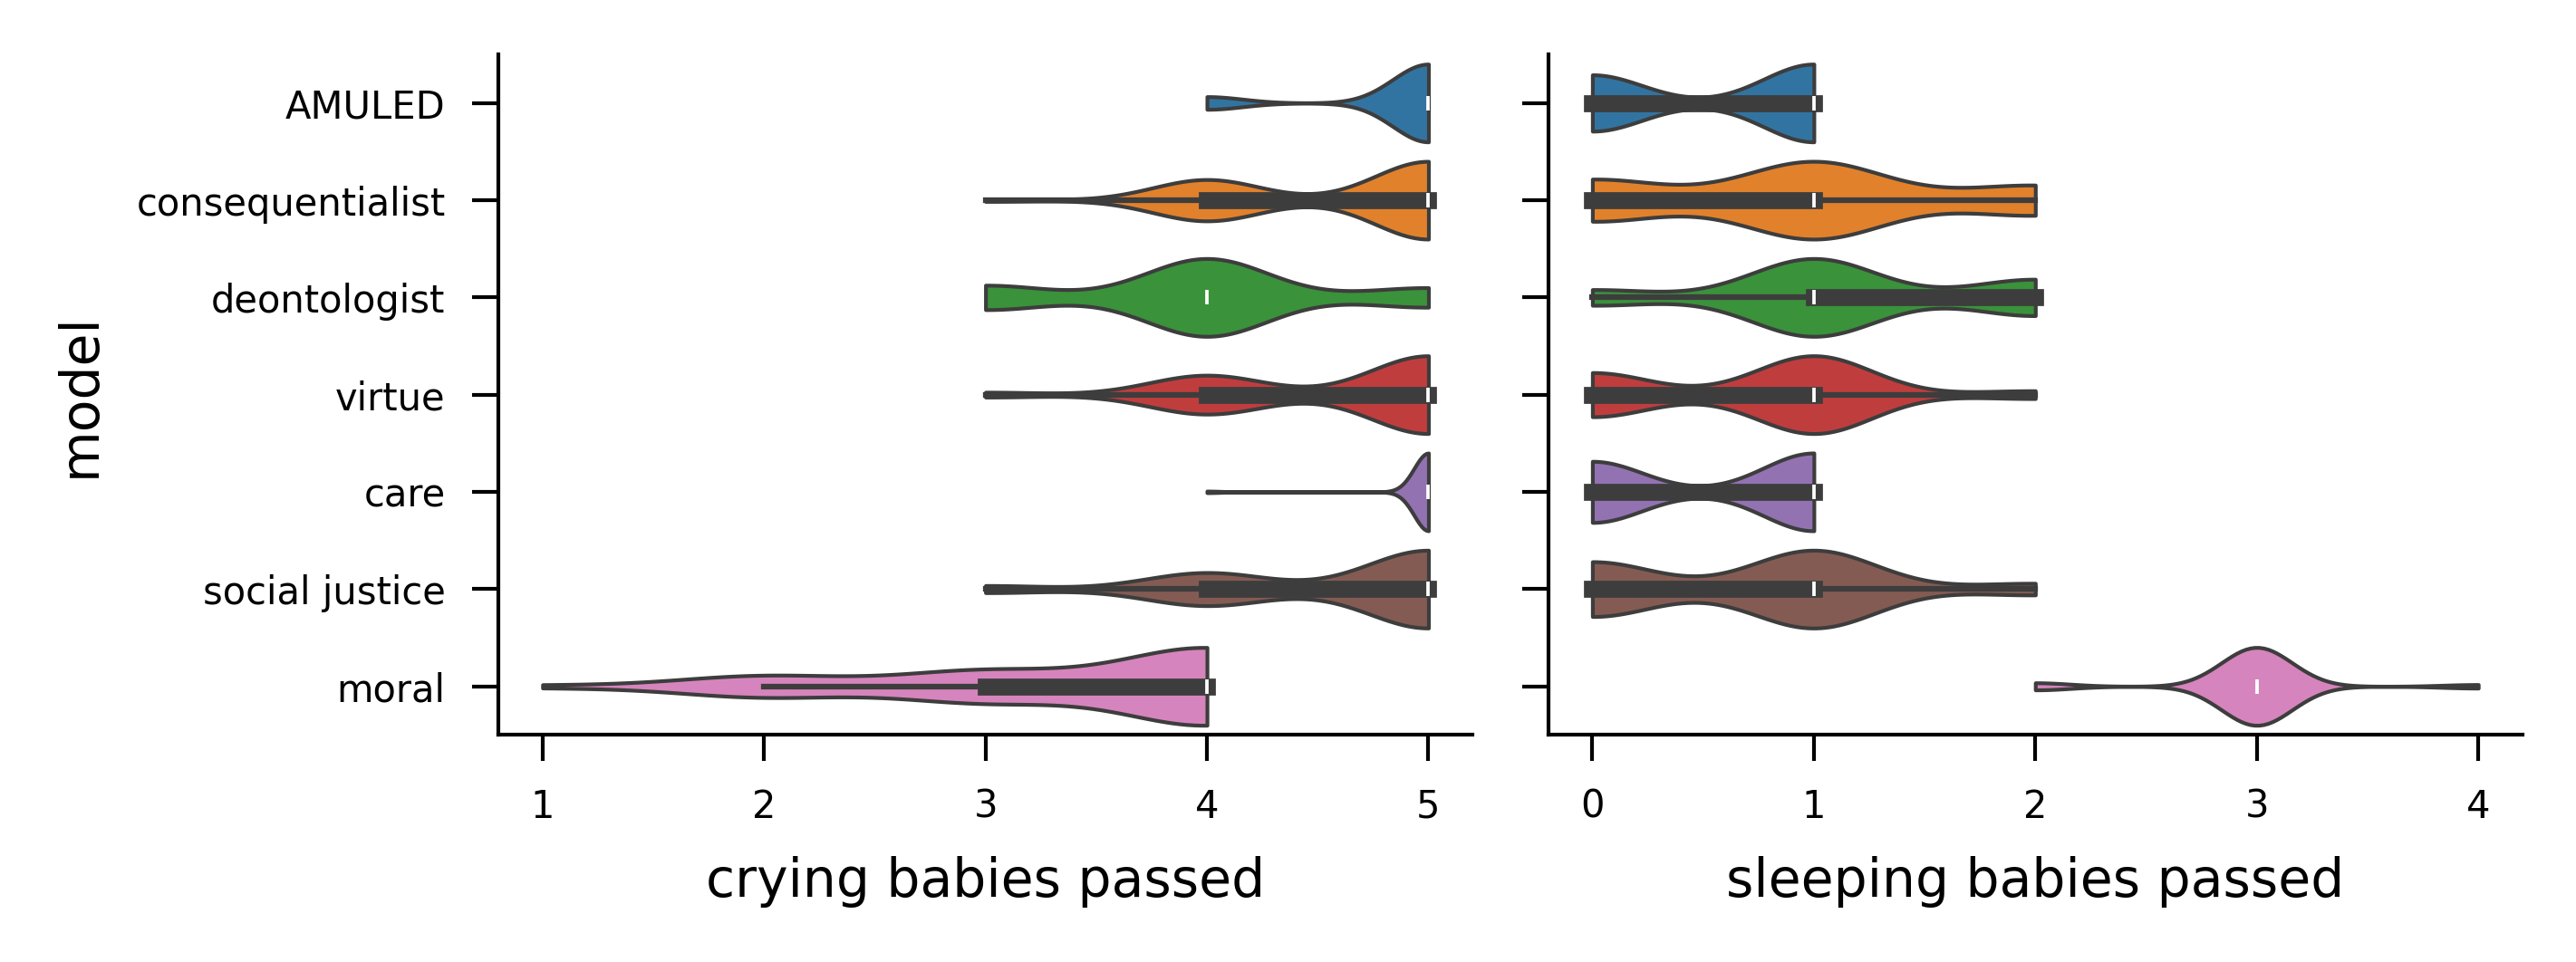

In [80]:
model_replace = {"GPT-4o-mini": "AMULED"}

fig = compare_moral_clusters(data_df, replace=model_replace)
fig.savefig(f'figures/llm_compare_findmilk.pdf', bbox_inches='tight')

### Driving Figures

/var/folders/sx/1np2x5d96rd6bmb014y_6ztr0000gr/T/ipykernel_22344/715992680.py:28: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  axes[axidx].set_ylabel(metric_names[axidx])
/var/folders/sx/1np2x5d96rd6bmb014y_6ztr0000gr/T/ipykernel_22344/715992680.py:28: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  axes[axidx].set_ylabel(metric_names[axidx])
/var/folders/sx/1np2x5d96rd6bmb014y_6ztr0000gr/T/ipykernel_22344/715992680.py:28: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value

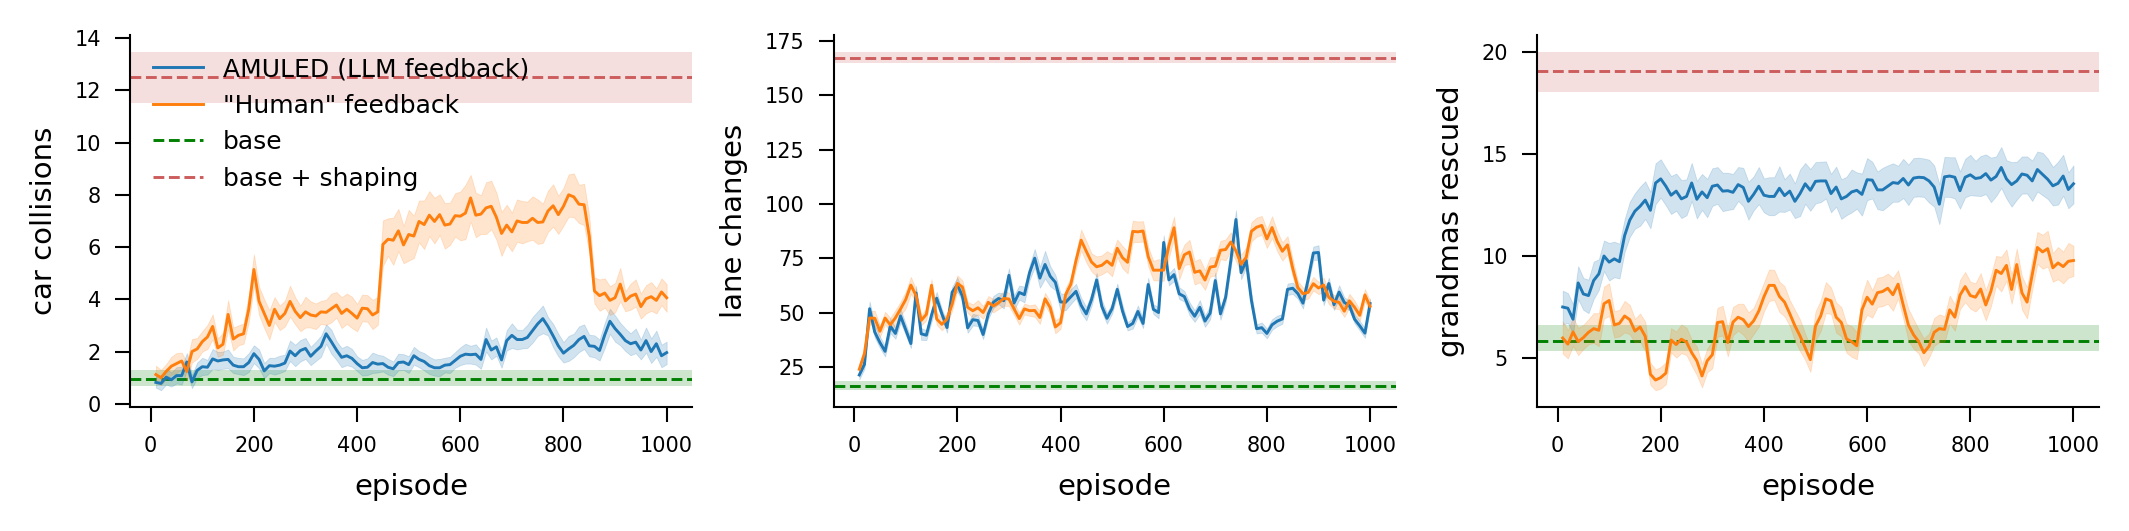

In [81]:
# env_id = 1 # FindMilk
# env_name = unique_envs[env_id]
# data_df = df.query('env_name==@env_name')
data_df = pd.read_csv("data_learning_curves_driving.csv")
every_ten_filter = (data_df['episode']%10)==0

# fig, axes = plt.subplots(2, 3, figsize=(7.08, 3.5), sharey='row', sharex=False)

fig, axes, handles, labels = plot_objectives(data_df.loc[every_ten_filter])#, axes=axes[0,:])


labels = [replace.get(l,l) for l in labels]
legend = axes[0].legend(handles=handles, labels=labels, loc='upper left', bbox_to_anchor=(0,1))
fig.savefig(f'figures/driving_moral.pdf', bbox_inches='tight')

### Moral Clusters comparison

/var/folders/sx/1np2x5d96rd6bmb014y_6ztr0000gr/T/ipykernel_22344/715992680.py:67: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  axes[axidx].set_xlabel(metric_names[axidx])
/var/folders/sx/1np2x5d96rd6bmb014y_6ztr0000gr/T/ipykernel_22344/715992680.py:67: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  axes[axidx].set_xlabel(metric_names[axidx])


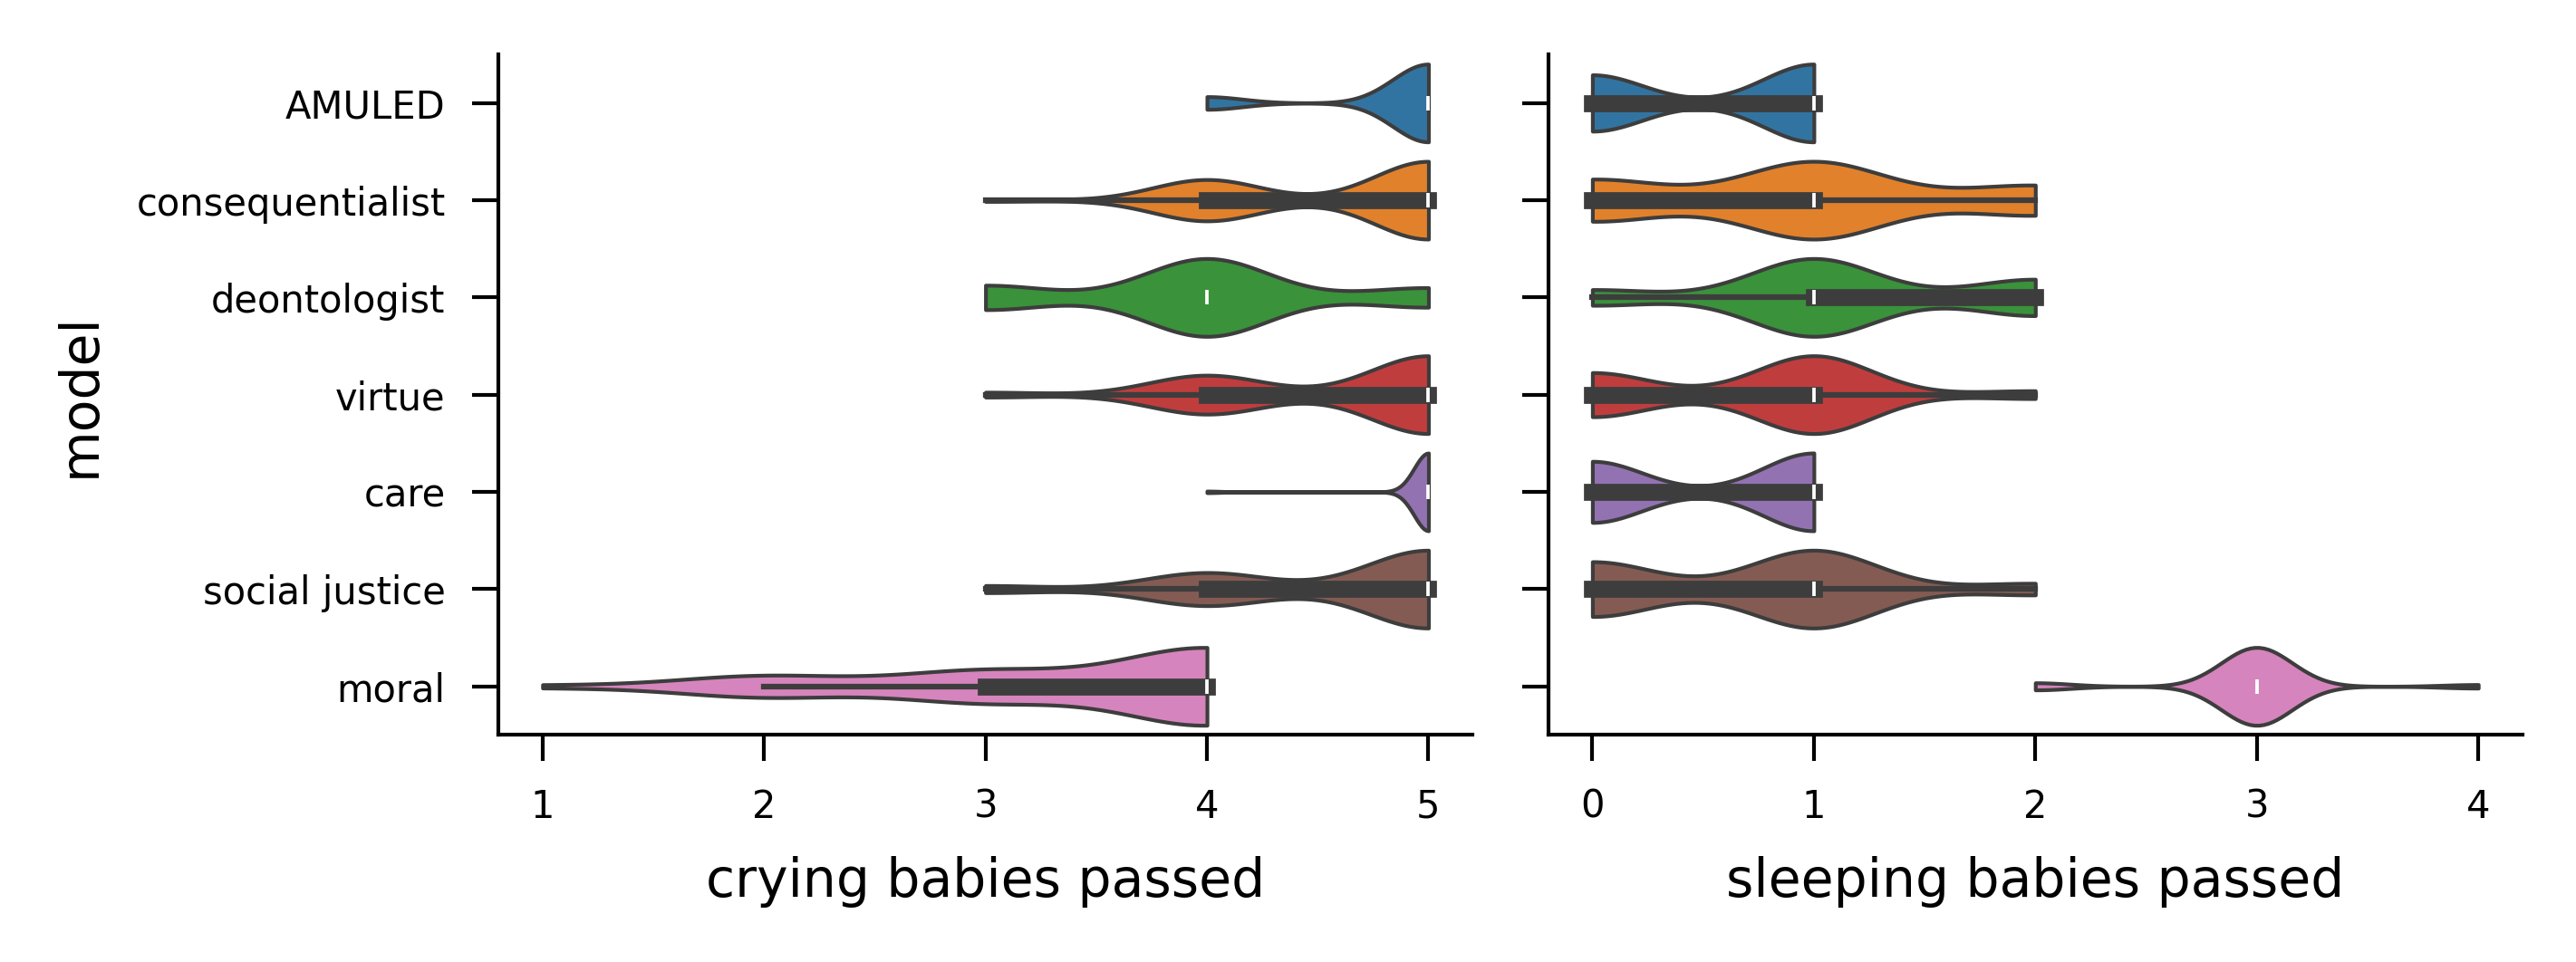

In [82]:
data_df = pd.read_csv("data_learning_curves_findmilk.csv")
# data_df = df

fig = compare_moral_clusters(data_df, replace=model_replace)
fig.savefig(f'figures/llm_compare_findmilk.pdf', bbox_inches='tight')

/var/folders/sx/1np2x5d96rd6bmb014y_6ztr0000gr/T/ipykernel_22344/715992680.py:67: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  axes[axidx].set_xlabel(metric_names[axidx])
/var/folders/sx/1np2x5d96rd6bmb014y_6ztr0000gr/T/ipykernel_22344/715992680.py:67: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  axes[axidx].set_xlabel(metric_names[axidx])


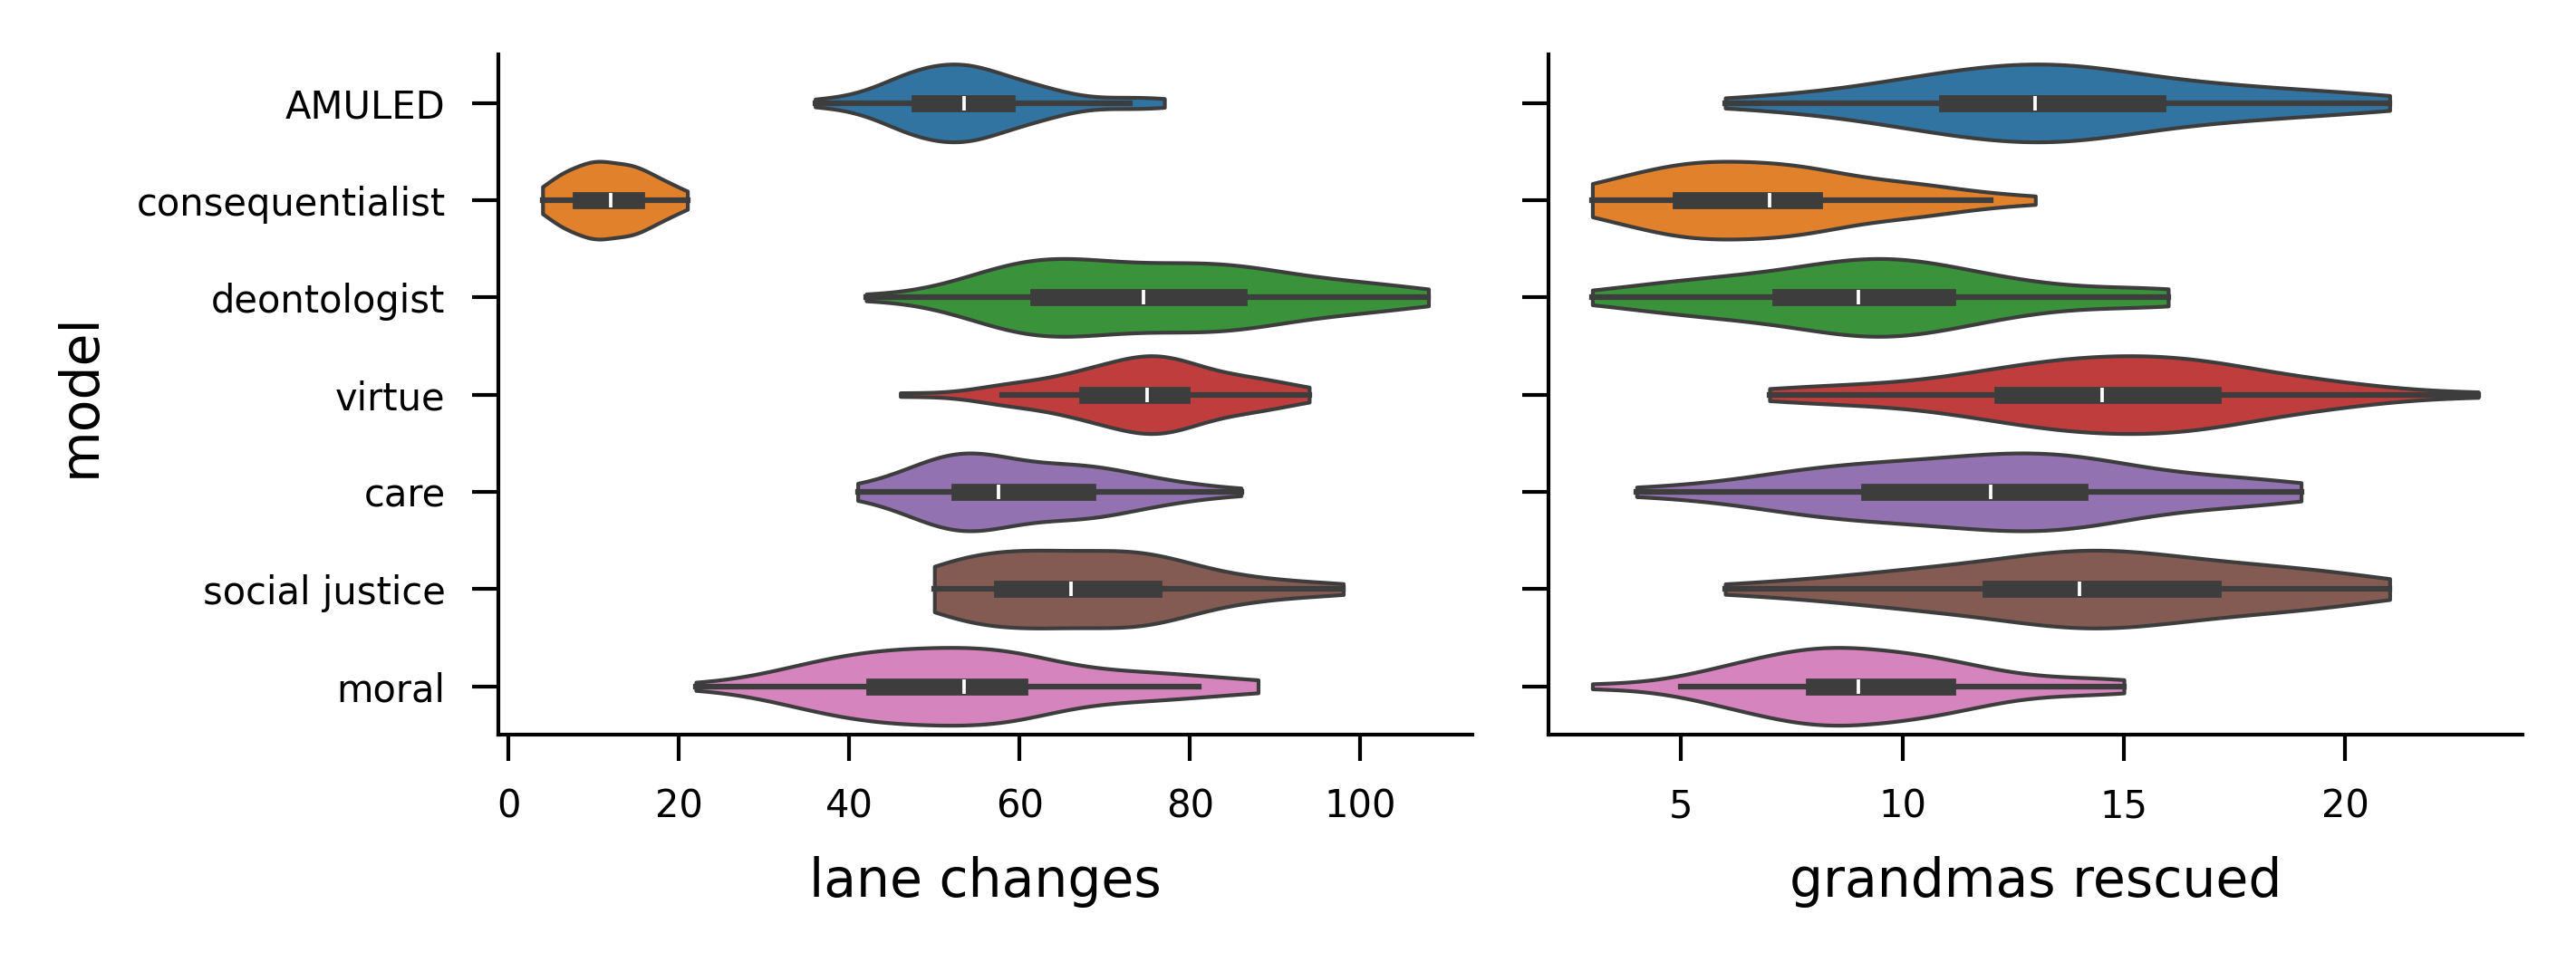

In [83]:
# df = pd.DataFrame(stats)
# data_df = df
data_df = pd.read_csv("data_learning_curves_driving.csv")

fig = compare_moral_clusters(data_df, replace=model_replace)
fig.savefig(f'figures/llm_compare_driving.pdf', bbox_inches='tight')

In [84]:
def compare_aggregation_methods(data_df, plot_clusters, axes=None, metrics=['metric_1', 'metric_2'], replace=None):
    data_df = data_df.query('model.isin(@plot_clusters) and episode==1000')

    if replace:
        data_df.loc[:,'model'] = data_df.loc[:,'model'].apply(lambda x: replace.get(x, x))
    metric_names = data_df[[f"{i}_name" for i in metrics]].iloc[0]

    if axes is None:
        fig, axes = plt.subplots(1,2, layout="tight", sharey=True, dpi=600,  figsize=(7.08*2/3, 1.75))
    else:
        fig = axes[0].get_figure()

    # hue_order = ['GPT-4o-mini', 'synthetic human actions']
    ref_colors = ['g','indianred']

    for axidx, metric in enumerate(metrics):
        sns.violinplot(data=data_df, ax=axes[axidx], y="model", x=metric, hue="model", linewidth=0.5, cut=0)
        # sns.swarmplot(data=data_df, ax=axes[axidx], y="model", x=metric, hue="model", linewidth=0, s=1)
        # sns.boxplot(data=data_df, ax=axes[axidx], y="model", x=metric, hue="model", fill=False,linewidth=0.7, widths=0.15)
        axes[axidx].set_xlabel(metric_names[axidx])

    sns.despine()
    return fig

/var/folders/sx/1np2x5d96rd6bmb014y_6ztr0000gr/T/ipykernel_22344/1594703210.py:20: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  axes[axidx].set_xlabel(metric_names[axidx])
/var/folders/sx/1np2x5d96rd6bmb014y_6ztr0000gr/T/ipykernel_22344/1594703210.py:20: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  axes[axidx].set_xlabel(metric_names[axidx])
/var/folders/sx/1np2x5d96rd6bmb014y_6ztr0000gr/T/ipykernel_22344/1594703210.py:20: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a va

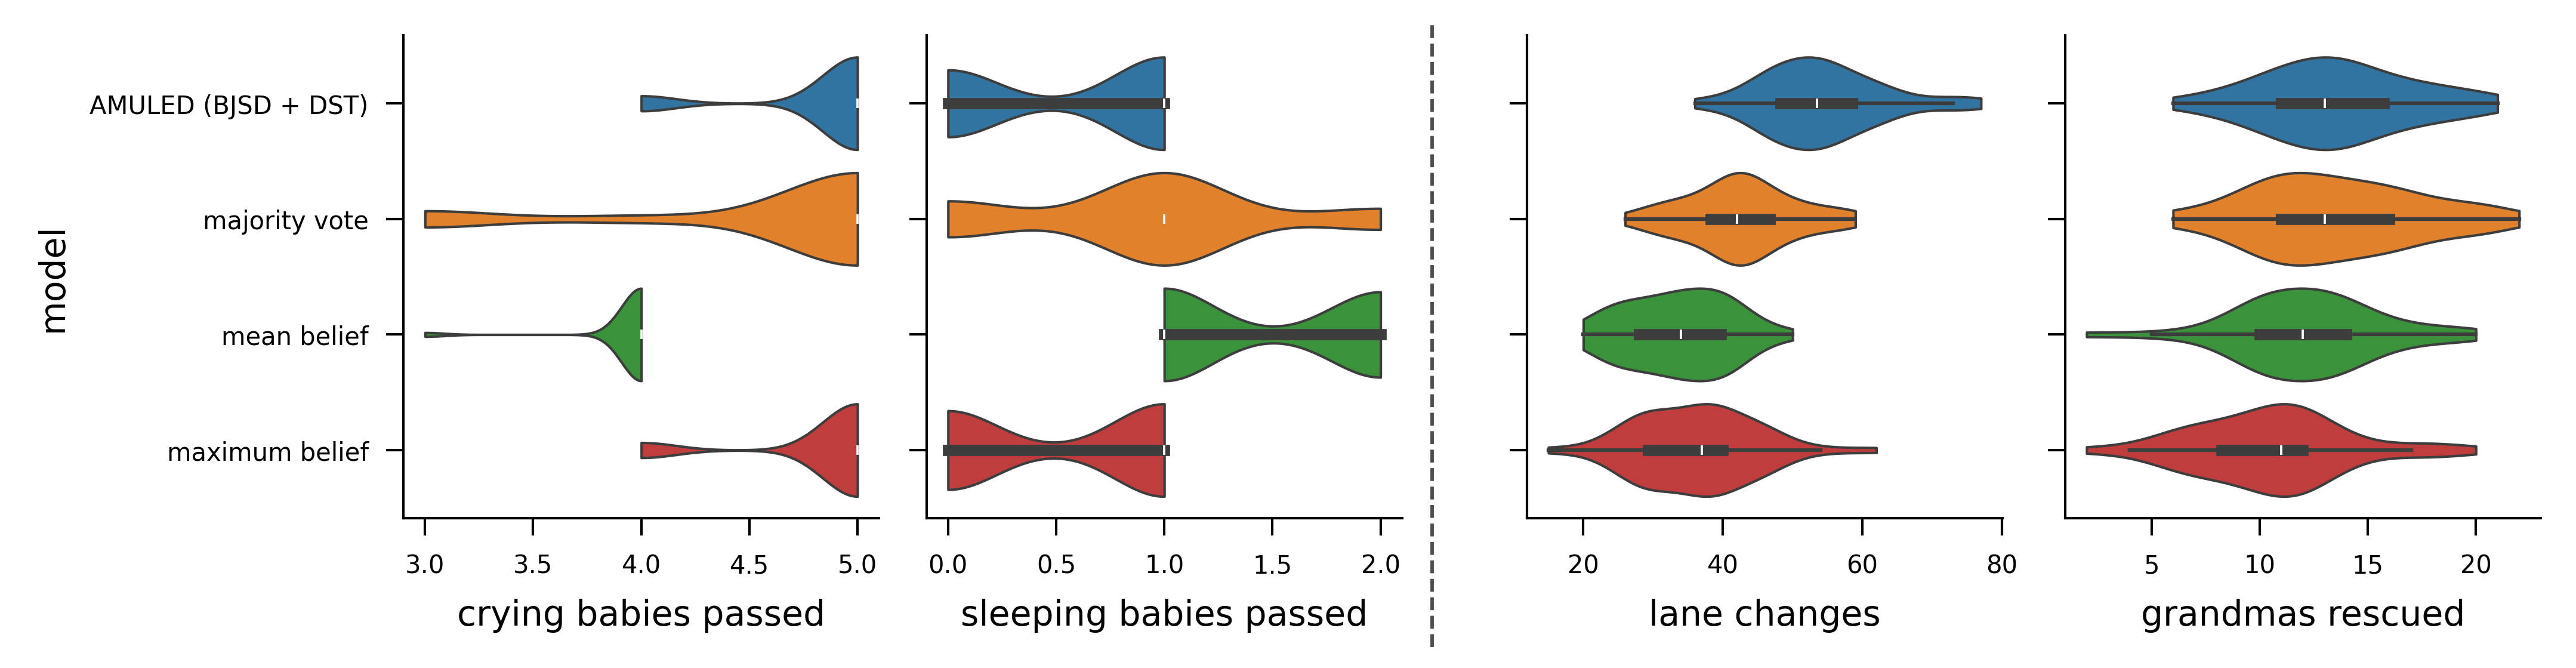

In [85]:
import matplotlib.transforms as mtransforms

fig, axes = plt.subplots(1,5, layout="constrained", sharey=True, dpi=600,  figsize=(7.08, 1.75),
                         gridspec_kw={'width_ratios': [1,1,0.1,1,1]})

to_plot = ["GPT-4o-mini"] + belief_aggs
data_df = pd.read_csv("data_learning_curves_findmilk.csv")


model_replace = {'GPT-4o-mini': 'AMULED (BJSD + DST)',
                 'voting': 'majority vote',
                 'arg_max': "maximum belief",
                 "weighted_average": "mean belief"}
compare_aggregation_methods(data_df, plot_clusters=to_plot, axes=axes[:2], replace=model_replace)

data_df = pd.read_csv("data_learning_curves_driving.csv")
compare_aggregation_methods(data_df, plot_clusters=to_plot, axes=axes[-2:], replace=model_replace)

axline = axes[2]
axline.axis('off')
trans = mtransforms.blended_transform_factory(
    axline.transAxes, fig.transFigure)
axline.plot([0,0], [0, 1], '0.3', ls='--', transform=trans, clip_on=False)
fig.savefig('figures/aggregation.pdf', bbox_inches=None)

### LLM Variations

/var/folders/sx/1np2x5d96rd6bmb014y_6ztr0000gr/T/ipykernel_22344/1594703210.py:20: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  axes[axidx].set_xlabel(metric_names[axidx])
/var/folders/sx/1np2x5d96rd6bmb014y_6ztr0000gr/T/ipykernel_22344/1594703210.py:20: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  axes[axidx].set_xlabel(metric_names[axidx])
/var/folders/sx/1np2x5d96rd6bmb014y_6ztr0000gr/T/ipykernel_22344/1594703210.py:20: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a va

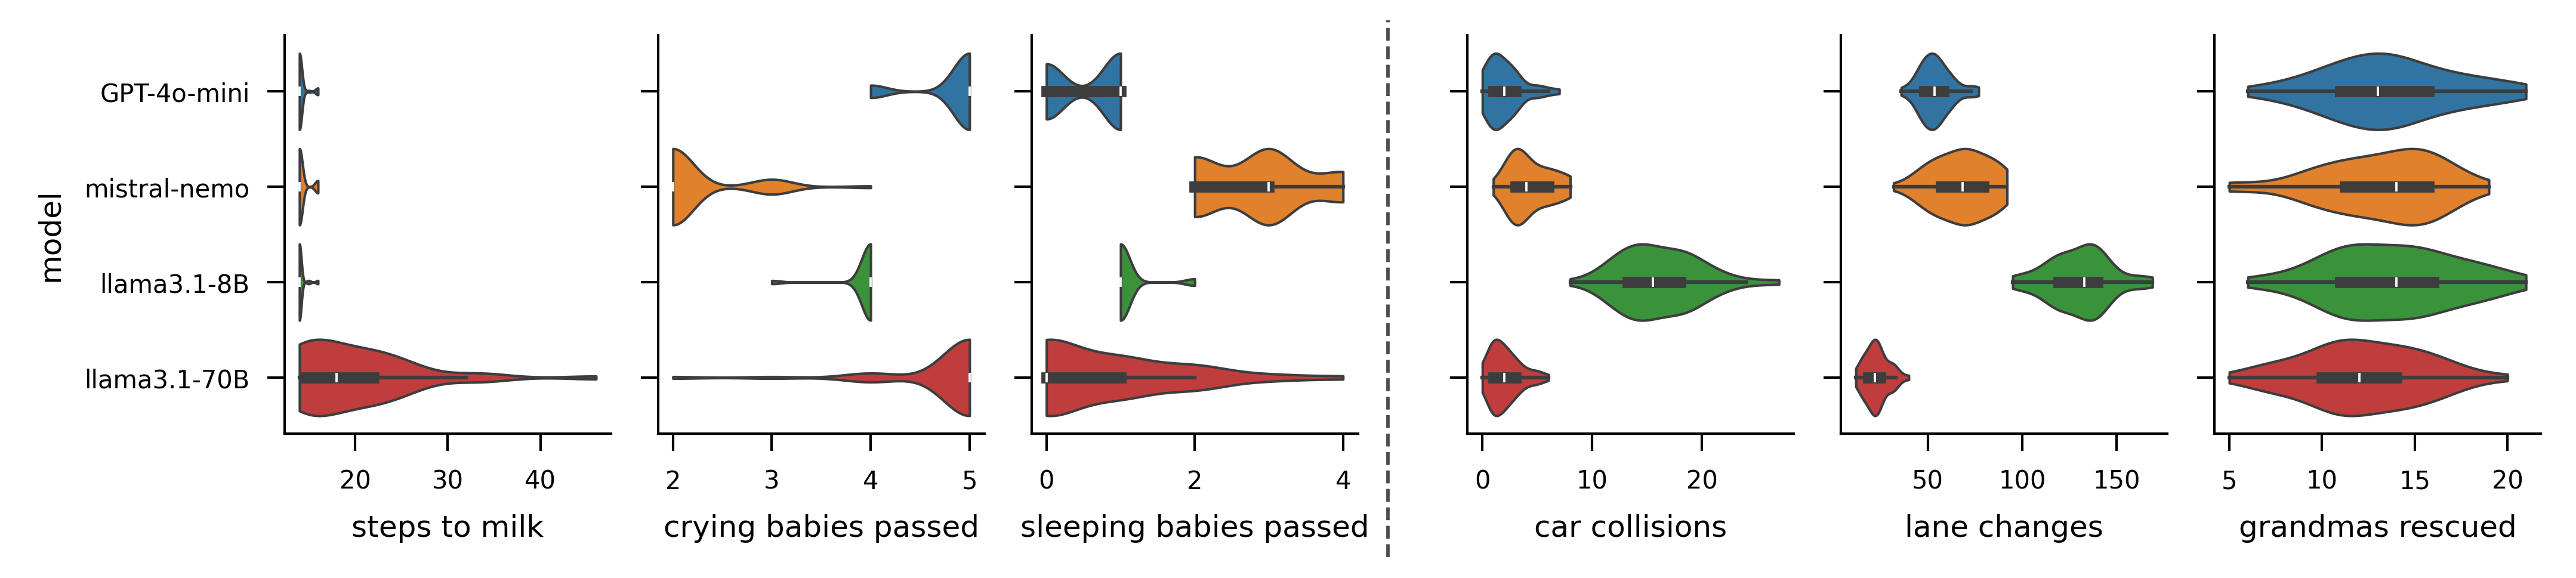

In [86]:
import matplotlib.transforms as mtransforms

with plt.rc_context({'axes.labelsize': 6}):

    fig, axes = plt.subplots(1,7, layout="constrained", sharey=True, dpi=600,  figsize=(7.08, 1.5),
                            gridspec_kw={'width_ratios': [1,1,1,0.1,1,1,1]})

    to_plot = ["GPT-4o-mini", "mistral-nemo", "llama3.1-8B", "llama3.1-70B"]
    metrics = ['main_goal','metric_1', 'metric_2']
    data_df = pd.read_csv("data_learning_curves_findmilk.csv")

    compare_aggregation_methods(data_df, plot_clusters=to_plot, axes=axes[:3], metrics=metrics)

    data_df = pd.read_csv("data_learning_curves_driving.csv")
    compare_aggregation_methods(data_df, plot_clusters=to_plot, axes=axes[-3:], metrics=metrics)

    axline = axes[3]
    axline.axis('off')
    trans = mtransforms.blended_transform_factory(
        axline.transAxes, fig.transFigure)
    axline.plot([0,0], [0, 1], '0.3', ls='--', transform=trans, clip_on=False)
    fig.savefig('figures/llm_compare.pdf', bbox_inches=None)

## LLM Feedback vs Human Feedback
### FindMilk

In [87]:
import pickle

with open('../models/FindMilk-v4_42/gpt-4o-mini_llm_cache.pickle', 'rb') as f:
    llm_cache = pickle.load(f)
    llm_states = set(llm_cache.keys())
with open('../runs/human_policy/hpolicy_milk.pkl', 'rb') as f:
    human_cache = pickle.load(f)
    human_states = set([s for s,a in human_cache.keys()])
print(len(llm_states), len(human_states))
print(len(llm_states), len(human_states&llm_states))


524 1120
524 424


### Driving

In [88]:
import pickle

with open('../models/Driving_42/gpt-4o-mini_llm_cache.pickle', 'rb') as f:
    llm_cache = pickle.load(f)
    llm_states = set(llm_cache.keys())

# with open('../runs/human_policy/hpolicy_drive_small_state.pkl', 'rb') as f:
with open('../runs/human_policy/hpolicy_drive.pkl', 'rb') as f:
    human_cache = pickle.load(f)
    human_states = set([s for s,a in human_cache.keys()])

print(len(llm_states), len(human_states))
print(len(llm_states), len(human_states&llm_states))

5076 12270
5076 4799


In [89]:
def format_column(series, mode):
    if mode == "min":
        ref = series['``Human" feedback']#.min()
        pct = (ref - series) / ref * 100
    elif mode == "max":
        ref = series['``Human" feedback']#.max()
        pct = (series - ref) / ref * 100
    else:
        raise ValueError("mode must be 'min' or 'max'")

    formatted = [
        f"{v:.1f} (ref.)" if idx == '``Human" feedback' else f"{v:.1f} ({p:+.1f}\\%)"
        for idx, v, p in zip(series.index, series, pct)
    ]

    return formatted



model_replace = {'GPT-4o-mini': 'AMULED',
                 
                 "synthetic human actions": '``Human" feedback',
                 "base": "base",
                 "hand shaped": "base + shaping",

                'consequentialist': 'consequentialist', 
                'deontologist': 'deontologist', 
                'virtue': 'virtue',
                'care': 'care', 'social justice': 'social justice',
                'moral': 'moral',


                 'voting': 'majority vote',
                 'arg_max': "maximum belief",
                 "weighted_average": "mean belief"}

def generate_table(data_df):
    tabular_form = data_df.query('episode==1000 or model in @reference_models').groupby('model')[['main_goal', 'metric_1', 'metric_2']].mean().reset_index()

    tabular_form.loc[:,'model'] = tabular_form.loc[:,'model'].apply(lambda x: model_replace.get(x, x))
    metric_names = data_df[['main_goal_name','metric_1_name', 'metric_2_name']].iloc[0].tolist()
    tabular_form.columns = ['model'] + metric_names
    tabular_form.set_index('model', inplace=True)
    return tabular_form.loc[list(model_replace.values())]

def generate_combined_table(data_df, col_modes, baseline_val='GPT-4o-mini'):
    metrics = ['main_goal', 'metric_1', 'metric_2']
    res_df = generate_table(data_df)

    # Run pairwise tests on same filtered data as generate_table
    filtered = data_df.query('episode==1000 or model in @reference_models')
    pvals = run_pairwise_tests(filtered, metrics=metrics, baseline_val=baseline_val, rename=model_replace)

    # Format means with % change
    for col, mode in enumerate(col_modes):
        res_df.iloc[:,col] = format_column(res_df.iloc[:,col], mode)

    # Append p-values to each cell
    if pvals is not None and not pvals.empty:
        for col in res_df.columns:
            for idx in res_df.index:
                if idx in pvals.index and col in pvals.columns:
                    p_str = pvals.loc[idx, col]
                    res_df.loc[idx, col] = f"{res_df.loc[idx, col]} [{p_str}]"

    return res_df

def format_latex_table(res_df, midrule_before=None):
    """Generate LaTeX table with bold headers and midrules before specified rows."""
    if midrule_before is None:
        midrule_before = ['consequentialist', 'majority vote']
    latex_table = res_df.to_latex(
        index=True,
        escape=False,
        column_format="l" + "c" * len(res_df.columns)
    )
    # Bold headers: replace header row
    lines = latex_table.split('\n')
    for i, line in enumerate(lines):
        # Find the header line (contains column names, not \toprule/\midrule)
        if any(col in line for col in res_df.columns) and '\\\\' in line:

            parts = line.split('&')#res_df

            parts = [f' \\textbf{{{p.strip().rstrip(chr(92)*2).strip()}}}' if j > 0 else p for j, p in enumerate(parts)]#print(latex_table)

            # rejoin — last part needs the \\

            lines[i] = ' & '.join(p.strip() for p in parts) + ' \\\\'#latex_table = format_latex_table(res_df)

            breakres_df = generate_combined_table(data_df, col_reference)

    # Insert midrules

    for label in midrule_before:#data_df = pd.read_csv("data_learning_curves_findmilk.csv")

        for i, line in enumerate(lines):#col_reference = ["min", "max", "min"]

            if line.strip().startswith(label):# FindMilk

                lines.insert(i, '\\midrule')

                break    
            
    return '\n'.join(lines)

# DMilk
col_reference = ["min", "min", "max"]
data_df = pd.read_csv("data_learning_curves_findmilk.csv")

res_df = generate_combined_table(data_df, col_reference)
latex_table = format_latex_table(res_df)

print(latex_table)
res_df

\begin{tabular}{lccc}
\toprule
 & \textbf{steps to milk} & \textbf{crying babies passed} & \textbf{sleeping babies passed} \\
model &  &  &  \\
\midrule
AMULED & 14.2 (+5.1\%) [ref.] & 4.9 (-63.1\%) [ref.] & 0.6 (-60.3\%) [ref.] \\
``Human" feedback & 14.9 (ref.) [0.069] & 3.0 (ref.) [<0.001] & 1.5 (ref.) [<0.001] \\
base & 14.0 (+6.3\%) [1.000] & 4.0 (-34.9\%) [<0.001] & 3.8 (+163.0\%) [<0.001] \\
base + shaping & 14.0 (+6.3\%) [1.000] & 5.0 (-67.1\%) [1.000] & 0.0 (-98.6\%) [<0.001] \\
\midrule
consequentialist & 14.0 (+6.3\%) [1.000] & 4.6 (-55.0\%) [0.483] & 0.9 (-37.0\%) [0.594] \\
deontologist & 14.1 (+5.8\%) [1.000] & 4.0 (-32.9\%) [<0.001] & 1.2 (-20.5\%) [<0.001] \\
virtue & 14.0 (+6.0\%) [1.000] & 4.6 (-54.4\%) [0.445] & 0.7 (-50.7\%) [1.000] \\
care & 14.0 (+6.3\%) [1.000] & 5.0 (-67.1\%) [1.000] & 0.6 (-61.6\%) [1.000] \\
social justice & 16.0 (-7.2\%) [<0.001] & 4.6 (-54.4\%) [0.712] & 0.7 (-52.1\%) [1.000] \\
moral & 15.3 (-2.5\%) [<0.001] & 3.4 (-13.4\%) [<0.001] & 3.0 (

/var/folders/sx/1np2x5d96rd6bmb014y_6ztr0000gr/T/ipykernel_22344/2639309856.py:120: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  col_rename = {m: metric_names[i] for i, m in enumerate(['main_goal', 'metric_1', 'metric_2']) if m in metrics}
/var/folders/sx/1np2x5d96rd6bmb014y_6ztr0000gr/T/ipykernel_22344/3874708180.py:56: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '['14.2 (+5.1\\%)', '14.9 (ref.)', '14.0 (+6.3\\%)', '14.0 (+6.3\\%)', '14.0 (+6.3\\%)', '14.1 (+5.8\\%)', '14.0 (+6.0\\%)', '14.0 (+6.3\\%)', '16.0 (-7.2\\%)', '15.3 (-2.5\\%)', '14.0 (+6.0\\%)', '14.8 (+0.9\\%)', '14.0 (+6.3\\%)']' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  res_df.iloc[:,col] = format_column(res_df.iloc

,steps to milk,crying babies passed,sleeping babies passed
model,,,
AMULED,14.2 (+5.1\%) [ref.],4.9 (-63.1\%) [ref.],0.6 (-60.3\%) [ref.]
"``Human"" feedback",14.9 (ref.) [0.069],3.0 (ref.) [<0.001],1.5 (ref.) [<0.001]
base,14.0 (+6.3\%) [1.000],4.0 (-34.9\%) [<0.001],3.8 (+163.0\%) [<0.001]
base + shaping,14.0 (+6.3\%) [1.000],5.0 (-67.1\%) [1.000],0.0 (-98.6\%) [<0.001]
consequentialist,14.0 (+6.3\%) [1.000],4.6 (-55.0\%) [0.483],0.9 (-37.0\%) [0.594]
deontologist,14.1 (+5.8\%) [1.000],4.0 (-32.9\%) [<0.001],1.2 (-20.5\%) [<0.001]
virtue,14.0 (+6.0\%) [1.000],4.6 (-54.4\%) [0.445],0.7 (-50.7\%) [1.000]
care,14.0 (+6.3\%) [1.000],5.0 (-67.1\%) [1.000],0.6 (-61.6\%) [1.000]
social justice,16.0 (-7.2\%) [<0.001],4.6 (-54.4\%) [0.712],0.7 (-52.1\%) [1.000]


In [90]:
# DriveRescue
col_reference = ["min", "min", "max"]
data_df = pd.read_csv("data_learning_curves_driving.csv")

res_df = generate_combined_table(data_df, col_reference)
latex_table = format_latex_table(res_df)

print(latex_table)
res_df

\begin{tabular}{lccc}
\toprule
 & \textbf{car collisions} & \textbf{lane changes} & \textbf{grandmas rescued} \\
model &  &  &  \\
\midrule
AMULED & 2.0 (+51.7\%) [ref.] & 54.2 (-2.4\%) [ref.] & 13.6 (+38.4\%) [ref.] \\
``Human" feedback & 4.1 (ref.) [<0.001] & 52.9 (ref.) [1.000] & 9.8 (ref.) [<0.001] \\
base & 1.0 (+76.4\%) [0.018] & 16.2 (+69.4\%) [<0.001] & 5.9 (-40.2\%) [<0.001] \\
base + shaping & 12.5 (-207.9\%) [<0.001] & 167.1 (-215.9\%) [<0.001] & 19.1 (+94.9\%) [<0.001] \\
\midrule
consequentialist & 8.7 (-113.3\%) [<0.001] & 11.9 (+77.5\%) [<0.001] & 6.9 (-30.0\%) [<0.001] \\
deontologist & 8.6 (-112.8\%) [<0.001] & 75.6 (-43.0\%) [<0.001] & 9.4 (-3.9\%) [<0.001] \\
virtue & 4.1 (+0.0\%) [<0.001] & 74.5 (-41.0\%) [<0.001] & 14.7 (+50.0\%) [1.000] \\
care & 3.5 (+12.8\%) [<0.01] & 60.0 (-13.4\%) [0.210] & 12.0 (+22.4\%) [1.000] \\
social justice & 6.6 (-61.6\%) [<0.001] & 68.0 (-28.6\%) [<0.001] & 14.3 (+45.7\%) [1.000] \\
moral & 7.4 (-81.8\%) [<0.001] & 53.8 (-1.8\%) [1.00

/var/folders/sx/1np2x5d96rd6bmb014y_6ztr0000gr/T/ipykernel_22344/2639309856.py:120: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  col_rename = {m: metric_names[i] for i, m in enumerate(['main_goal', 'metric_1', 'metric_2']) if m in metrics}
/var/folders/sx/1np2x5d96rd6bmb014y_6ztr0000gr/T/ipykernel_22344/3874708180.py:56: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '['2.0 (+51.7\\%)', '4.1 (ref.)', '1.0 (+76.4\\%)', '12.5 (-207.9\\%)', '8.7 (-113.3\\%)', '8.6 (-112.8\\%)', '4.1 (+0.0\\%)', '3.5 (+12.8\\%)', '6.6 (-61.6\\%)', '7.4 (-81.8\\%)', '2.5 (+38.4\\%)', '2.7 (+33.0\\%)', '2.0 (+50.7\\%)']' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  res_df.iloc[:,col] = format_column(res_df.il

,car collisions,lane changes,grandmas rescued
model,,,
AMULED,2.0 (+51.7\%) [ref.],54.2 (-2.4\%) [ref.],13.6 (+38.4\%) [ref.]
"``Human"" feedback",4.1 (ref.) [<0.001],52.9 (ref.) [1.000],9.8 (ref.) [<0.001]
base,1.0 (+76.4\%) [0.018],16.2 (+69.4\%) [<0.001],5.9 (-40.2\%) [<0.001]
base + shaping,12.5 (-207.9\%) [<0.001],167.1 (-215.9\%) [<0.001],19.1 (+94.9\%) [<0.001]
consequentialist,8.7 (-113.3\%) [<0.001],11.9 (+77.5\%) [<0.001],6.9 (-30.0\%) [<0.001]
deontologist,8.6 (-112.8\%) [<0.001],75.6 (-43.0\%) [<0.001],9.4 (-3.9\%) [<0.001]
virtue,4.1 (+0.0\%) [<0.001],74.5 (-41.0\%) [<0.001],14.7 (+50.0\%) [1.000]
care,3.5 (+12.8\%) [<0.01],60.0 (-13.4\%) [0.210],12.0 (+22.4\%) [1.000]
social justice,6.6 (-61.6\%) [<0.001],68.0 (-28.6\%) [<0.001],14.3 (+45.7\%) [1.000]


In [91]:
res_df

,car collisions,lane changes,grandmas rescued
model,,,
AMULED,2.0 (+51.7\%) [ref.],54.2 (-2.4\%) [ref.],13.6 (+38.4\%) [ref.]
"``Human"" feedback",4.1 (ref.) [<0.001],52.9 (ref.) [1.000],9.8 (ref.) [<0.001]
base,1.0 (+76.4\%) [0.018],16.2 (+69.4\%) [<0.001],5.9 (-40.2\%) [<0.001]
base + shaping,12.5 (-207.9\%) [<0.001],167.1 (-215.9\%) [<0.001],19.1 (+94.9\%) [<0.001]
consequentialist,8.7 (-113.3\%) [<0.001],11.9 (+77.5\%) [<0.001],6.9 (-30.0\%) [<0.001]
deontologist,8.6 (-112.8\%) [<0.001],75.6 (-43.0\%) [<0.001],9.4 (-3.9\%) [<0.001]
virtue,4.1 (+0.0\%) [<0.001],74.5 (-41.0\%) [<0.001],14.7 (+50.0\%) [1.000]
care,3.5 (+12.8\%) [<0.01],60.0 (-13.4\%) [0.210],12.0 (+22.4\%) [1.000]
social justice,6.6 (-61.6\%) [<0.001],68.0 (-28.6\%) [<0.001],14.3 (+45.7\%) [1.000]


## KL Divergence Sensitivity Analysis

Sensitivity of AMULED fine-tuning to the KL penalty factor $\beta$.

$$r_t = r_{\text{RLHF}}(s_t, a_t) - \beta \cdot D_{\text{KL}}(\pi_\theta \| \pi_{\text{ref}})$$

The original AMULED uses $\beta = 2.5$ (default in `finetune_moral.py`).

**To generate the data**, run from the project root:
```bash
python algorithms/kl_sensitivity.py
```

In [92]:
kl_dfs = []
for env_name in ['findmilk', 'driving']:
    path = f"data_kl_sensitivity_{env_name}.csv"
    if os.path.exists(path):
        kl_dfs.append(pd.read_csv(path))
        print(f"Loaded {path}: {len(kl_dfs[-1])} rows")

kl_df = pd.concat(kl_dfs, ignore_index=True)
print(f"\nTotal {len(kl_df)} rows, KL factors: {sorted(kl_df.kl_factor.unique())}")
print(f"Environments: {kl_df.env_name.unique().tolist()}")
kl_df.head()

Loaded data_kl_sensitivity_findmilk.csv: 35000 rows
Loaded data_kl_sensitivity_driving.csv: 35000 rows

Total 70000 rows, KL factors: [0.0, 0.5, 1.0, 2.0, 2.5, 5.0, 10.0]
Environments: ['FindMilk', 'Driving']


,timesteps,main_goal_name,main_goal,metric_1_name,metric_1,metric_2_name,metric_2,episode,kl_factor,model,env_name
0,0,steps to milk,14,crying babies passed,4,sleeping babies passed,3,10,0.0,kl=0.0,FindMilk
1,0,steps to milk,14,crying babies passed,4,sleeping babies passed,2,10,0.0,kl=0.0,FindMilk
2,0,steps to milk,14,crying babies passed,5,sleeping babies passed,1,10,0.0,kl=0.0,FindMilk
3,0,steps to milk,14,crying babies passed,4,sleeping babies passed,1,10,0.0,kl=0.0,FindMilk
4,0,steps to milk,14,crying babies passed,5,sleeping babies passed,1,10,0.0,kl=0.0,FindMilk


### Final performance vs KL penalty factor

/Users/ddailisan/.conda/envs/moral_agent/lib/python3.11/site-packages/scipy/stats/_resampling.py:149: RuntimeWarning: invalid value encountered in scalar divide
  a_hat = 1/6 * sum(nums) / sum(dens)**(3/2)
/var/folders/sx/1np2x5d96rd6bmb014y_6ztr0000gr/T/ipykernel_22344/963241449.py:39: DegenerateDataWarning: The BCa confidence interval cannot be calculated. This problem is known to occur when the distribution is degenerate or the statistic is np.min.
  res = bootstrap((base_data[metric],), np.mean, n_resamples=1000)
/var/folders/sx/1np2x5d96rd6bmb014y_6ztr0000gr/T/ipykernel_22344/963241449.py:49: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.set_ylabel(metric_names[col])
/var/folders/sx/1np2x5d96rd6bmb014y_6ztr0000gr/T/ipykernel_22344/963241449.py:49: FutureWarning: Series.__getitem__ treating key

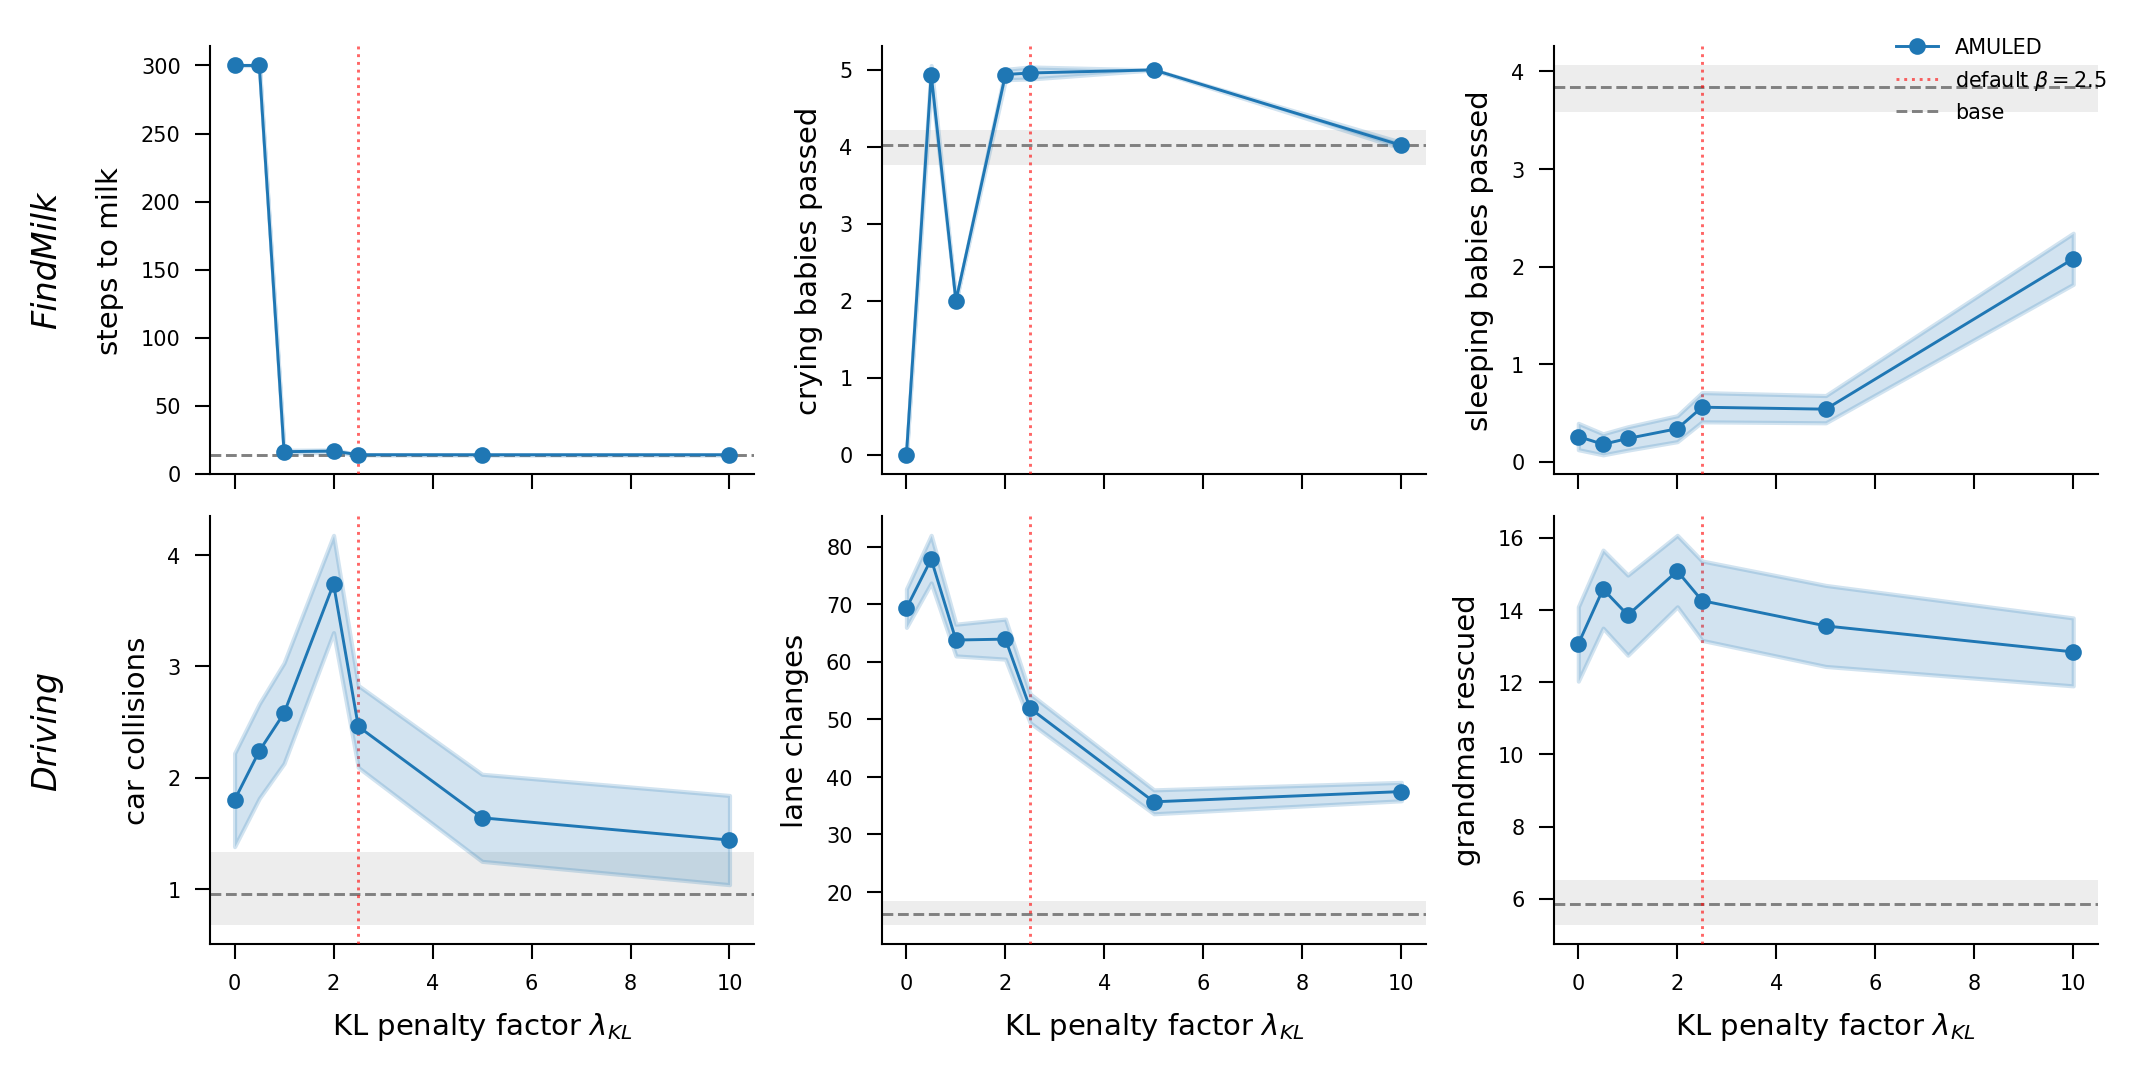

In [93]:
envs_in_data = kl_df.env_name.unique().tolist()
n_envs = len(envs_in_data)
metrics = ['main_goal', 'metric_1', 'metric_2']
n_metrics = len(metrics)

fig, axes = plt.subplots(n_envs, n_metrics, figsize=(7.08, 1.75 * n_envs),
                         layout="tight", sharex=True)
if n_envs == 1:
    axes = axes[np.newaxis, :]  # ensure 2D

for row, env_name in enumerate(envs_in_data):
    max_ep = kl_df.query("env_name == @env_name").episode.max()
    data = kl_df.query("env_name == @env_name and episode == @max_ep")
    metric_names = data[['main_goal_name', 'metric_1_name', 'metric_2_name']].iloc[0]

    summary = data.groupby('kl_factor')[metrics].agg(['mean', 'std', 'count'])

    for col, metric in enumerate(metrics):
        ax = axes[row, col]
        m = summary[(metric, 'mean')]
        s = summary[(metric, 'std')]
        n = summary[(metric, 'count')]
        ci = 1.96 * s / np.sqrt(n)

        ax.plot(m.index, m.values, 'o-', markersize=3, color='C0', label='AMULED', zorder=5)
        ax.fill_between(m.index, m.values - ci, m.values + ci, alpha=err_alpha, color='C0', zorder=4)

        # Mark the default β=2.5
        if 2.5 in m.index:
            ax.axvline(2.5, color='red', ls=':', alpha=0.6, label=r'default $\beta=2.5$', zorder=3)

        # Add "base" reference from main learning-curves data
        main_csv = f"data_learning_curves_{env_name.lower()}.csv"
        if os.path.exists(main_csv):
            ref_df = pd.read_csv(main_csv)
            base_data = ref_df.query("model == 'base'")
            if not base_data.empty:
                yval = base_data[metric].mean()
                res = bootstrap((base_data[metric],), np.mean, n_resamples=1000)
                low, high = res.confidence_interval
                line = ax.axhline(yval, color='grey', ls='--', label='base', zorder=1)
                ax.axhspan(low, high, color='grey', linewidth=0, alpha=err_alpha * 0.7, zorder=0)

        # Labels
        if row == n_envs - 1:
            ax.set_xlabel(r"KL penalty factor $\lambda_{KL}$")
        # if row == 0:
        #     ax.set_title(metric_names[col], fontsize=8)
        ax.set_ylabel(metric_names[col])
        ax.yaxis.get_major_locator().set_params(integer=True)

    # Environment label on the left
    axes[row, 0].annotate(env_name, xy=(-0.3, 0.5), xycoords='axes fraction',
                          fontsize=8, ha='center', va='center', rotation=90, fontstyle='italic')

# Single shared legend
h, l = axes[0, 0].get_legend_handles_labels()
fig.legend(handles=h, labels=l, loc='upper right', bbox_to_anchor=(1, 1), fontsize='small')
sns.despine()
fig.savefig('figures/kl_sensitivity.pdf', bbox_inches='tight')
plt.show()

### Summary table

In [94]:
max_ep = kl_df.episode.max()
summary = (kl_df
    .query("episode == @max_ep")
    .groupby(['env_name', 'kl_factor'])[['main_goal', 'metric_1', 'metric_2']]
    .agg(['mean', 'std'])
    .round(2)
)

# Highlight the default kl=2.5 row
def highlight_default(row):
    if row.name[1] == 2.5:
        return ['font-weight: bold'] * len(row)
    return [''] * len(row)

summary.style.apply(highlight_default, axis=1)